## Modelo Selecionado

Com base no recall obtido na validação, usamos a **melhor variante de SGDClassifier**
(entre os modelos cujo nome contém `SGD Classifier`) para apoio ao diagnóstico de diabetes.


## Preparação do Ambiente

Nesta seção:
- adicionamos `src/` ao `sys.path` para reutilizar funções do projeto
- importamos bibliotecas de análise e visualização
- importamos `shap` para explicações (globais e locais)

A ideia aqui é interpretar o modelo final, conectando o comportamento do classificador com as variáveis clínicas.


In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from train import train_models
from preprocessing import preprocess_data


## Carregamento do modelo final

Reaproveitamos a função de treino para obter:
- os modelos treinados (`models`)
- o conjunto de teste (`X_test`, `y_test`)

Em seguida selecionamos automaticamente a **melhor variante de SGDClassifier por recall de validação**.


In [4]:
results, models, (X_test, y_test) = train_models()

sgd_candidates = {
    name: metrics
    for name, metrics in results.items()
    if "SGD Classifier" in name
}

best_model_name = max(sgd_candidates, key=lambda name: sgd_candidates[name]["recall"])
best_model = models[best_model_name]

print(f"Using final model for interpretability: {best_model_name}")



Experimento 1 (sgd): pop=20, gens=20, mutation=0.1
[sgd] Geração 0 - Melhor fitness: 0.7521
[sgd] Geração 1 - Melhor fitness: 0.7521
[sgd] Geração 2 - Melhor fitness: 0.7877
[sgd] Geração 3 - Melhor fitness: 0.7877
[sgd] Geração 4 - Melhor fitness: 0.7877
[sgd] Geração 5 - Melhor fitness: 0.7877
[sgd] Geração 6 - Melhor fitness: 0.7877
[sgd] Geração 7 - Melhor fitness: 0.7877
[sgd] Geração 8 - Melhor fitness: 0.7877
[sgd] Geração 9 - Melhor fitness: 0.7877
[sgd] Geração 10 - Melhor fitness: 0.7877
[sgd] Geração 11 - Melhor fitness: 0.7877
[sgd] Geração 12 - Melhor fitness: 0.7877
[sgd] Geração 13 - Melhor fitness: 0.7877
[sgd] Geração 14 - Melhor fitness: 0.7915
[sgd] Geração 15 - Melhor fitness: 0.7915
[sgd] Geração 16 - Melhor fitness: 0.7915
[sgd] Geração 17 - Melhor fitness: 0.7915
[sgd] Geração 18 - Melhor fitness: 0.7915
[sgd] Geração 19 - Melhor fitness: 0.7915

Experimento 2 (sgd): pop=30, gens=25, mutation=0.2
[sgd] Geração 0 - Melhor fitness: 0.7443
[sgd] Geração 1 - Melhor 

## Recuperando nomes das features após o pré-processamento

Como o pipeline aplica transformações (ex.: padronização via `ColumnTransformer`), é importante recuperar os nomes das features na mesma ordem usada pelo modelo.

Isso permite associar corretamente cada coeficiente/efeito à variável correspondente.


In [5]:
_, _, _, _, _, _, preprocessor = preprocess_data()
feature_names = preprocessor.get_feature_names_out()


## Importância baseada em coeficientes (modelo linear)

O `SGDClassifier` (com perda logística/hinge, dependendo da configuração) é um modelo linear, então seus **coeficientes** indicam direção e intensidade do efeito (no espaço transformado).

Como as variáveis foram padronizadas, comparar magnitudes absolutas dos coeficientes costuma ser razoável.
- coeficiente **positivo**: aumenta a tendência à classe positiva (diabetes)
- coeficiente **negativo**: diminui a tendência

Aqui montamos uma tabela ordenando pelos maiores valores em magnitude.


In [6]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_model.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

coef_df


,feature,coefficient
1,num__Glucose,2.285718
0,num__Pregnancies,0.836278
5,num__BMI,0.792468
6,num__DiabetesPedigreeFunction,0.762841
3,num__SkinThickness,0.000000
2,num__BloodPressure,0.000000
4,num__Insulin,0.000000
7,num__Age,0.000000


### Visualização dos coeficientes

O gráfico abaixo ajuda a ver rapidamente:
- quais variáveis empurram a decisão para “diabetes” (lado positivo)
- quais variáveis puxam para “não diabetes” (lado negativo)

A linha vertical em 0 separa os sinais.


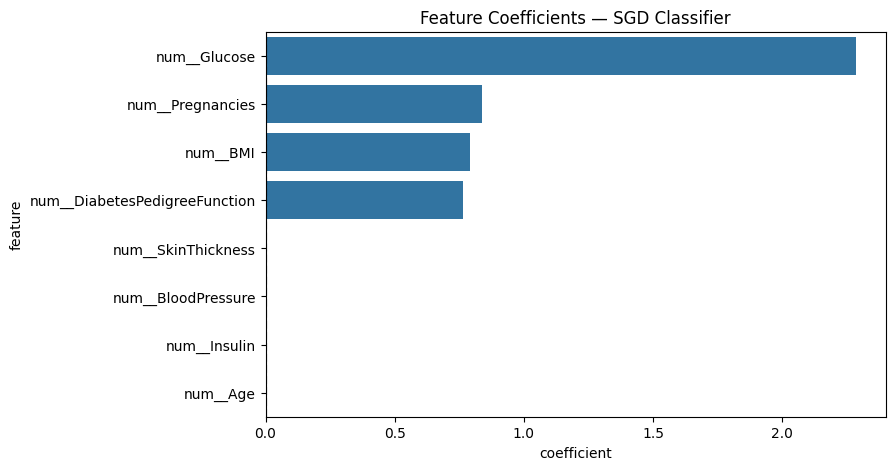

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_df,
    x="coefficient",
    y="feature"
)
plt.title("Feature Coefficients — SGD Classifier")
plt.axvline(0, color="black", linestyle="--")
plt.show()

## Interpretabilidade com SHAP (visão global)

Além dos coeficientes, usamos SHAP para explicar o modelo em termos de **contribuição de cada feature** na predição.

O *summary plot* (gráfico de resumo) mostra, globalmente:
- quais variáveis mais impactam o modelo (ordem por importância)
- como valores altos/baixos dessas variáveis tendem a empurrar a predição para a classe positiva/negativa

Dica de leitura:
- o eixo horizontal representa o efeito (valor SHAP): à direita tende a aumentar a probabilidade da classe positiva; à esquerda, diminuir.


C:\Users\lucc-\AppData\Local\Temp\ipykernel_24076\1365926243.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


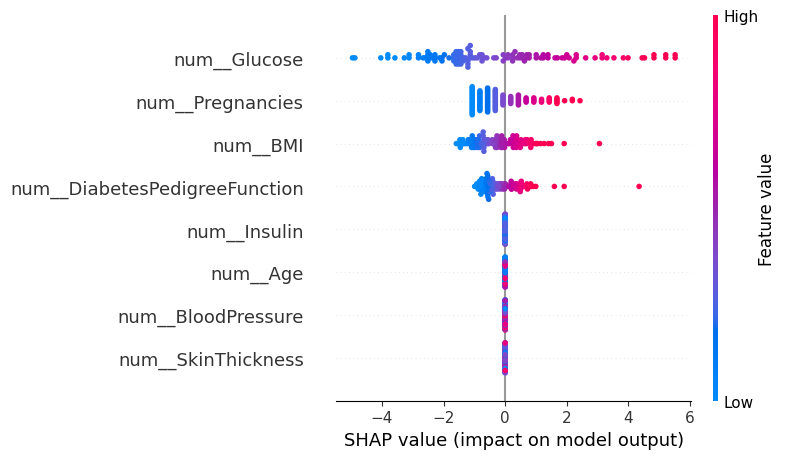

In [8]:
X_train, _, X_test, y_train, _, y_test, _ = preprocess_data()

explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)


## Interpretabilidade local (waterfall)

O gráfico *waterfall* explica **uma predição individual**.

Como ler:
- começa em um valor base (média do modelo)
- cada barra mostra quanto uma feature empurra a predição para cima/baixo
- ao final, chegamos na pontuação do modelo para aquele paciente (amostra)

Aqui escolhemos `sample_idx = 0`, mas você pode trocar para analisar outros casos, inclusive um falso positivo/falso negativo.


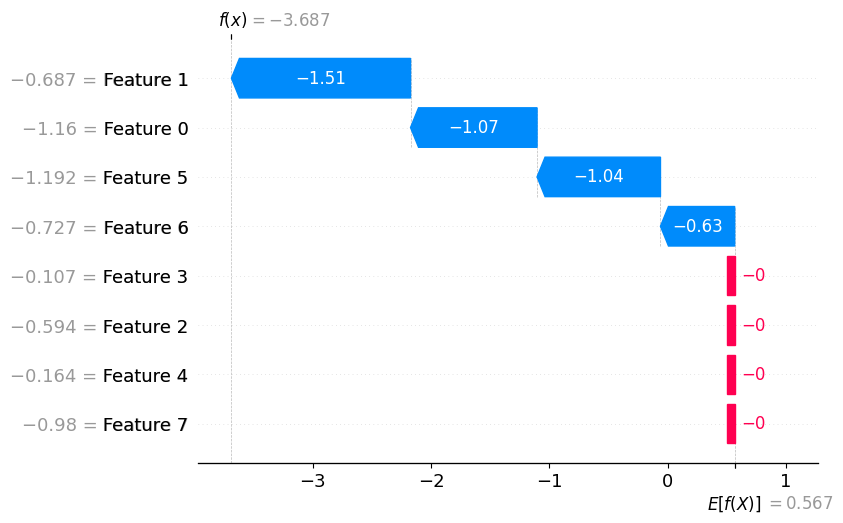

In [9]:
sample_idx = 0

shap.plots.waterfall(
    shap_values[sample_idx],
)


## Conclusões sobre a Interpretabilidade

A análise de interpretabilidade confirma que o nível de glicose é a
característica mais importante que influencia a predição de diabetes,
seguida pelo IMC (Índice de Massa Corporal) e pela idade.  
Tanto a análise dos coeficientes quanto as explicações por meio do SHAP
são consistentes com o conhecimento clínico, reforçando a confiabilidade
do modelo.
